### Подготовка окружения

В этой ячейке устанавливаются основные библиотеки, которые используются в лабораторной работе: `ultralytics` для YOLO, инструменты для чтения датасетов, визуализации и расчёта метрик. Ноутбук теперь ориентирован на запуск в Google Colab, поэтому после выполнения этой ячейки среда должна быть полностью готова без локальной настройки `.venv`.


In [1]:
%pip install ultralytics roboflow h5py pyyaml opencv-python pillow tqdm pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


### Импорт зависимостей

Здесь подключаются все модули, которые понадобятся далее: работа с файлами, изображениями, табличными данными, `PyTorch`, `Ultralytics YOLO` и вспомогательные библиотеки. После выполнения этой ячейки ноутбук получает весь базовый инструментарий для подготовки данных, обучения и оценки модели.

In [2]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import shutil
import sys
import tarfile
import urllib.request
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from ultralytics import YOLO
from roboflow import Roboflow


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Конфигурация эксперимента

Эта ячейка задаёт общие параметры всей лабораторной работы: имя базовой модели, размер изображения, размер батча, число эпох, пороги `confidence` и `IoU`, а также пути ко всем рабочим папкам. Теперь она автоматически определяет запуск в Google Colab, использует рабочую директорию внутри `/content` и убирает жёсткую зависимость от локального Windows-окружения.


In [3]:
def running_in_colab() -> bool:
    return 'google.colab' in sys.modules


IS_COLAB = running_in_colab()
try:
    from google.colab import files as colab_files
except Exception:
    colab_files = None


DEFAULT_COLAB_ROOT = Path('/content/itmo_cv_lab2')
SVHN_TRAIN_URL = 'http://ufldl.stanford.edu/housenumbers/train.tar.gz'
SVHN_TEST_URL = 'http://ufldl.stanford.edu/housenumbers/test.tar.gz'
IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def default_project_root() -> Path:
    env_root = os.getenv('LAB2_PROJECT_ROOT')
    if env_root:
        return Path(env_root).expanduser().resolve()
    if IS_COLAB:
        return DEFAULT_COLAB_ROOT
    return Path.cwd().resolve()


@dataclass
class LabConfig:
    seed: int = 123
    model_name: str = 'yolo11n.pt'
    img_size: int = 640
    batch_size: int = 128
    workers: int = 16
    device: int | str = 0
    stage1_epochs: int = 6
    stage2_epochs: int = 18
    patience: int = 8
    conf_threshold: float = 0.25
    iou_threshold: float = 0.50
    val_part: float = 0.10
    debug_fraction: float = 1.0
    reuse_existing_runs: bool = True

    project_root: Path = field(default_factory=default_project_root)
    raw_root: Path | None = None
    prepared_root: Path | None = None
    runs_root: Path | None = None
    model_root: Path | None = None
    inference_root: Path | None = None
    personal_photos_root: Path | None = None

    svhn_train_archive: Path | None = None
    svhn_test_archive: Path | None = None
    svhn_train_url: str = SVHN_TRAIN_URL
    svhn_test_url: str = SVHN_TEST_URL

    roboflow_api_key: str = "ZkMyrq2xqI9rPE7P7V8V"
    roboflow_workspace: str = 'university-of-toronto-xho85'
    roboflow_project: str = 'numberdetection-eppfj'
    roboflow_version: int = 2

    def __post_init__(self) -> None:
        self.project_root = Path(self.project_root).expanduser().resolve()
        self.raw_root = Path(self.raw_root) if self.raw_root else self.project_root / 'data' / 'raw'
        self.prepared_root = Path(self.prepared_root) if self.prepared_root else self.project_root / 'data' / 'prepared'
        self.runs_root = Path(self.runs_root) if self.runs_root else self.project_root / 'runs'
        self.model_root = Path(self.model_root) if self.model_root else self.project_root / 'models'
        self.inference_root = Path(self.inference_root) if self.inference_root else self.project_root / 'inference'
        self.personal_photos_root = Path(self.personal_photos_root) if self.personal_photos_root else self.project_root / 'my_photos'
        self.svhn_train_archive = Path(self.svhn_train_archive) if self.svhn_train_archive else self.project_root / 'train.tar.gz'
        self.svhn_test_archive = Path(self.svhn_test_archive) if self.svhn_test_archive else self.project_root / 'test.tar.gz'


def pick_runtime_device(device: int | str) -> int | str:
    device_name = str(device).strip().lower()
    if torch.cuda.is_available():
        return device
    if device_name in {'cpu', 'mps'}:
        return 'cpu'
    if device_name.startswith('cuda') or device_name.isdigit():
        return 'cuda'
    return 'cpu'


def build_config() -> LabConfig:
    cfg = LabConfig()
    cfg_candidates = [
        cfg.project_root / 'configs' / 'experiment.yaml',
        Path.cwd().resolve() / 'configs' / 'experiment.yaml',
    ]
    cfg_path = next((candidate for candidate in cfg_candidates if candidate.exists()), None)
    if cfg_path is not None:
        raw_cfg = yaml.safe_load(cfg_path.read_text(encoding='utf-8')) or {}
        for key, value in raw_cfg.items():
            if not hasattr(cfg, key) or value in (None, ''):
                continue
            if key.endswith('_root') or key.endswith('_archive'):
                value = (cfg.project_root / value).resolve() if not Path(value).is_absolute() else Path(value)
            setattr(cfg, key, value)
        cfg.__post_init__()
    cfg.device = pick_runtime_device(cfg.device)
    return cfg


CFG = build_config()
print('Runtime snapshot:')
print(f'  runtime: {"Google Colab" if IS_COLAB else "Local Jupyter"}')
print(f'  python executable: {sys.executable}')
print(f'  python version: {sys.version.split()[0]}')
print(f'  torch version: {torch.__version__}')
print(f'  torch cuda: {torch.version.cuda}')
print(f'  cuda available: {torch.cuda.is_available()}')
print(f'  cuda count: {torch.cuda.device_count()}')
if torch.cuda.is_available():
    print(f'  gpu: {torch.cuda.get_device_name(0)}')

if IS_COLAB:
    print('\nColab runtime detected. All files will be stored inside the project folder in /content unless LAB2_PROJECT_ROOT is set.')
else:
    local_python = CFG.project_root / '.venv' / ('Scripts' if os.name == 'nt' else 'bin') / 'python'
    if local_python.exists():
        kernel_ok = Path(sys.executable).resolve() == local_python.resolve()
        if kernel_ok:
            print('\nKernel OK: project virtual environment is active.')
        else:
            print('\nWARNING: project virtual environment is not active.')
            print(f'Expected Python: {local_python}')
    else:
        print('\nRunning outside Colab. No project-specific virtual environment check was enforced.')

for folder in [
    CFG.project_root,
    CFG.raw_root,
    CFG.prepared_root,
    CFG.runs_root,
    CFG.model_root,
    CFG.inference_root,
    CFG.personal_photos_root,
]:
    folder.mkdir(parents=True, exist_ok=True)

SVHN_DATA_YAML = CFG.prepared_root / 'svhn_full_sequence.yaml'
ROBOFLOW_DATA_YAML = CFG.raw_root / 'numberdetection' / 'data.yaml'
print('\nResolved config:')
print(CFG)
print(f'Photos directory: {CFG.personal_photos_root}')


Runtime snapshot:
  runtime: Google Colab
  python executable: /usr/bin/python3
  python version: 3.12.13
  torch version: 2.10.0+cu128
  torch cuda: 12.8
  cuda available: True
  cuda count: 1
  gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition

Colab runtime detected. All files will be stored inside the project folder in /content unless LAB2_PROJECT_ROOT is set.

Resolved config:
LabConfig(seed=123, model_name='yolo11n.pt', img_size=640, batch_size=128, workers=16, device=0, stage1_epochs=6, stage2_epochs=18, patience=8, conf_threshold=0.25, iou_threshold=0.5, val_part=0.1, debug_fraction=1.0, reuse_existing_runs=True, project_root=PosixPath('/content/itmo_cv_lab2'), raw_root=PosixPath('/content/itmo_cv_lab2/data/raw'), prepared_root=PosixPath('/content/itmo_cv_lab2/data/prepared'), runs_root=PosixPath('/content/itmo_cv_lab2/runs'), model_root=PosixPath('/content/itmo_cv_lab2/models'), inference_root=PosixPath('/content/itmo_cv_lab2/inference'), personal_photos_root=PosixPath('/conte

### Фиксация случайности

Для воспроизводимости результатов фиксируются генераторы случайных чисел в `random`, `numpy` и системных переменных Python. Это важно, чтобы разбиение выборки и обучение модели при повторном запуске вели себя максимально стабильно.

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(CFG.seed)

### Вспомогательные функции

Ниже собраны сервисные функции, которые используются в нескольких частях работы: скачивание и распаковка архивов, преобразование координат, чтение YOLO-разметки, вычисление `IoU`, визуализация bbox и построение графиков обучения. Такой блок позволяет не дублировать код и сделать дальнейшие ячейки более компактными и понятными.

In [5]:
def fetch_once(url: str, destination: Path) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        print(f'Already exists: {destination}')
        return destination
    print(f'Downloading: {url}')
    urllib.request.urlretrieve(url, destination)
    return destination


def unpack_tar_if_needed(archive_path: Path, expected_dir: Path) -> Path:
    if expected_dir.exists() and any(expected_dir.iterdir()):
        print(f'Already unpacked: {expected_dir}')
        return expected_dir
    expected_dir.parent.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(expected_dir.parent)
    return expected_dir


def list_image_files(folder: Path, suffixes: set[str] | None = None) -> list[Path]:
    suffixes = suffixes or IMAGE_SUFFIXES
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in suffixes])


def ensure_personal_photos(cfg: LabConfig) -> list[Path]:
    image_paths = list_image_files(cfg.personal_photos_root)
    if image_paths or not IS_COLAB or colab_files is None:
        return image_paths

    print('No photos were found in the personal photo folder.')
    print('Colab will open an upload dialog now. Select your 5-10 street photos from the local computer.')
    uploaded = colab_files.upload()
    for name, payload in uploaded.items():
        target = cfg.personal_photos_root / Path(name).name
        target.write_bytes(payload)
        print(f'Saved: {target}')
    return list_image_files(cfg.personal_photos_root)


def read_rgb_image(path: str | Path) -> np.ndarray:
    image = cv2.imread(str(path))
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def yolo_to_xyxy(row: list[float], image_w: int, image_h: int) -> list[float]:
    _, xc, yc, bw, bh = row
    x1 = (xc - bw / 2) * image_w
    y1 = (yc - bh / 2) * image_h
    x2 = (xc + bw / 2) * image_w
    y2 = (yc + bh / 2) * image_h
    return [x1, y1, x2, y2]


def xyxy_to_yolo(x1: float, y1: float, x2: float, y2: float, image_w: int, image_h: int) -> list[float]:
    x1 = max(0.0, min(x1, image_w - 1))
    y1 = max(0.0, min(y1, image_h - 1))
    x2 = max(0.0, min(x2, image_w - 1))
    y2 = max(0.0, min(y2, image_h - 1))
    bw = max(1e-6, x2 - x1)
    bh = max(1e-6, y2 - y1)
    xc = x1 + bw / 2
    yc = y1 + bh / 2
    return [xc / image_w, yc / image_h, bw / image_w, bh / image_h]


def load_yolo_boxes(label_path: Path, image_w: int, image_h: int) -> list[list[float]]:
    if not label_path.exists():
        return []
    records = []
    with open(label_path, 'r', encoding='utf-8') as fh:
        for line in fh:
            cls_id, xc, yc, bw, bh = map(float, line.strip().split())
            x1, y1, x2, y2 = yolo_to_xyxy([cls_id, xc, yc, bw, bh], image_w, image_h)
            records.append([int(cls_id), x1, y1, x2, y2])
    return records


def draw_xyxy_boxes(image: np.ndarray, boxes: list[list[float]], color=(255, 0, 0), width: int = 2) -> np.ndarray:
    output = image.copy()
    for _, x1, y1, x2, y2 in boxes:
        cv2.rectangle(output, (int(x1), int(y1)), (int(x2), int(y2)), color, width)
    return output


def show_random_examples(images_dir: Path, labels_dir: Path, n: int = 9, cols: int = 3, figsize=(14, 12)) -> None:
    image_paths = list_image_files(images_dir, {'.jpg', '.jpeg', '.png'})
    if not image_paths:
        print(f'No images found in {images_dir}')
        return
    chosen = random.sample(image_paths, min(n, len(image_paths)))
    rows = math.ceil(len(chosen) / cols)
    plt.figure(figsize=figsize)
    for i, image_path in enumerate(chosen, start=1):
        image = read_rgb_image(image_path)
        h, w = image.shape[:2]
        boxes = load_yolo_boxes(labels_dir / f'{image_path.stem}.txt', w, h)
        vis = draw_xyxy_boxes(image, boxes)
        plt.subplot(rows, cols, i)
        plt.imshow(vis)
        plt.title(image_path.name, fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def iou_xyxy(box_a: list[float], box_b: list[float]) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return 0.0 if union <= 0 else inter / union


def summarize_labels(images_dir: Path, labels_dir: Path) -> pd.DataFrame:
    rows = []
    for image_path in list_image_files(images_dir, {'.jpg', '.jpeg', '.png'}):
        image = read_rgb_image(image_path)
        h, w = image.shape[:2]
        boxes = load_yolo_boxes(labels_dir / f'{image_path.stem}.txt', w, h)
        if not boxes:
            continue
        _, x1, y1, x2, y2 = boxes[0]
        rows.append({
            'image': image_path.name,
            'width': w,
            'height': h,
            'bbox_area_ratio': ((x2 - x1) * (y2 - y1)) / max(1.0, w * h),
            'aspect_ratio': (x2 - x1) / max(1e-6, (y2 - y1)),
        })
    return pd.DataFrame(rows)


def plot_training_curves(results_csv: Path, title: str) -> None:
    if not results_csv.exists():
        print(f'File not found: {results_csv}')
        return
    df = pd.read_csv(results_csv)
    train_loss_cols = [c for c in df.columns if 'train' in c.lower() and 'loss' in c.lower()]
    val_loss_cols = [c for c in df.columns if 'val' in c.lower() and 'loss' in c.lower()]
    metric_cols = [c for c in df.columns if any(k in c.lower() for k in ['precision', 'recall', 'map'])]

    plt.figure(figsize=(14, 5))
    for col in train_loss_cols + val_loss_cols:
        plt.plot(df.index + 1, df[col], label=col)
    plt.title(f'{title}: loss')
    plt.xlabel('epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if metric_cols:
        plt.figure(figsize=(14, 5))
        for col in metric_cols:
            plt.plot(df.index + 1, df[col], label=col)
        plt.title(f'{title}: metrics')
        plt.xlabel('epoch')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


### Подготовка датасета SVHN

В этой ячейке исходный датасет SVHN переводится в формат, удобный для YOLO: из файла `digitStruct.mat` считываются координаты отдельных цифр, после чего они объединяются в один общий bounding box номера. Для запуска в Colab добавлена автоматическая загрузка архивов `train.tar.gz` и `test.tar.gz`, поэтому вручную подготавливать их заранее больше не требуется.


In [6]:
def _svhn_scalar(h5_file: h5py.File, value) -> float:
    try:
        return float(np.asarray(h5_file[value][()]).squeeze())
    except Exception:
        return float(np.asarray(value).squeeze())


def _svhn_text(h5_file: h5py.File, ref) -> str:
    data = np.asarray(h5_file[ref][()]).astype(np.uint8).squeeze()
    if data.ndim == 0:
        data = np.array([data])
    return ''.join(chr(int(x)) for x in data)


def read_digitstruct_records(mat_path: Path) -> list[dict]:
    records = []
    with h5py.File(mat_path, 'r') as h5_file:
        names = h5_file['digitStruct']['name']
        bboxes = h5_file['digitStruct']['bbox']
        for idx in tqdm(range(len(names)), desc=f'Reading {mat_path.parent.name}'):
            name_ref = names[idx][0]
            bbox_ref = bboxes[idx][0]
            bbox_group = h5_file[bbox_ref]
            sample = {'image_name': _svhn_text(h5_file, name_ref)}
            for key in ['label', 'left', 'top', 'width', 'height']:
                dataset = bbox_group[key]
                values = []
                for j in range(dataset.shape[0]):
                    values.append(_svhn_scalar(h5_file, dataset[j][0]))
                sample[key] = values
            records.append(sample)
    return records


def merge_digit_boxes(record: dict, image_w: int, image_h: int) -> list[float]:
    left = np.asarray(record['left'], dtype=float)
    top = np.asarray(record['top'], dtype=float)
    width = np.asarray(record['width'], dtype=float)
    height = np.asarray(record['height'], dtype=float)
    x1 = float(left.min())
    y1 = float(top.min())
    x2 = float((left + width).max())
    y2 = float((top + height).max())
    x1 = max(0.0, min(x1, image_w - 1))
    y1 = max(0.0, min(y1, image_h - 1))
    x2 = max(0.0, min(x2, image_w - 1))
    y2 = max(0.0, min(y2, image_h - 1))
    return [x1, y1, x2, y2]


def ensure_yolo_split_dirs(root: Path) -> None:
    for split in ['train', 'val', 'test']:
        (root / 'images' / split).mkdir(parents=True, exist_ok=True)
        (root / 'labels' / split).mkdir(parents=True, exist_ok=True)


def prepare_svhn_sequence_dataset(cfg: LabConfig) -> tuple[Path, pd.DataFrame]:
    train_archive = fetch_once(cfg.svhn_train_url, cfg.svhn_train_archive)
    test_archive = fetch_once(cfg.svhn_test_url, cfg.svhn_test_archive)

    train_dir = unpack_tar_if_needed(train_archive, cfg.raw_root / 'train')
    test_dir = unpack_tar_if_needed(test_archive, cfg.raw_root / 'test')

    output_root = cfg.prepared_root / 'svhn_full_sequence'
    manifest_path = cfg.prepared_root / 'svhn_manifest.csv'
    ensure_yolo_split_dirs(output_root)

    if manifest_path.exists() and SVHN_DATA_YAML.exists():
        print('SVHN is already prepared.')
        return SVHN_DATA_YAML, pd.read_csv(manifest_path)

    train_records = read_digitstruct_records(train_dir / 'digitStruct.mat')
    test_records = read_digitstruct_records(test_dir / 'digitStruct.mat')

    if cfg.debug_fraction < 1.0:
        rng = np.random.default_rng(cfg.seed)
        train_count = int(len(train_records) * cfg.debug_fraction)
        test_count = int(len(test_records) * cfg.debug_fraction)
        train_records = list(rng.choice(train_records, size=train_count, replace=False))
        test_records = list(rng.choice(test_records, size=test_count, replace=False))

    train_indices = list(range(len(train_records)))
    train_idx, val_idx = train_test_split(
        train_indices,
        test_size=cfg.val_part,
        random_state=cfg.seed,
        shuffle=True,
    )

    split_index = {('train', i): 'train' for i in train_idx}
    split_index.update({('train', i): 'val' for i in val_idx})
    split_index.update({('test', i): 'test' for i in range(len(test_records))})

    manifest_rows = []
    for source_split, records, source_dir in [
        ('train', train_records, train_dir),
        ('test', test_records, test_dir),
    ]:
        for idx, record in tqdm(list(enumerate(records)), desc=f'Converting {source_split}'):
            target_split = split_index[(source_split, idx)]
            src_img = source_dir / record['image_name']
            dst_img = output_root / 'images' / target_split / record['image_name']
            dst_label = output_root / 'labels' / target_split / f"{Path(record['image_name']).stem}.txt"

            with Image.open(src_img) as image:
                image_w, image_h = image.size

            x1, y1, x2, y2 = merge_digit_boxes(record, image_w, image_h)
            xc, yc, bw, bh = xyxy_to_yolo(x1, y1, x2, y2, image_w, image_h)

            shutil.copy2(src_img, dst_img)
            with open(dst_label, 'w', encoding='utf-8') as fh:
                fh.write(f'0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}')

            manifest_rows.append({
                'image_name': record['image_name'],
                'source_split': source_split,
                'yolo_split': target_split,
                'digits_count': len(record['label']),
                'sequence_text': ''.join(str(int(x) % 10) for x in record['label']),
                'x1': x1,
                'y1': y1,
                'x2': x2,
                'y2': y2,
            })

    manifest = pd.DataFrame(manifest_rows).sort_values(['yolo_split', 'image_name']).reset_index(drop=True)
    manifest.to_csv(manifest_path, index=False)

    dataset_yaml = {
        'path': str(output_root),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'names': {0: 'street_number'},
        'nc': 1,
    }
    with open(SVHN_DATA_YAML, 'w', encoding='utf-8') as fh:
        yaml.safe_dump(dataset_yaml, fh, sort_keys=False, allow_unicode=True)

    return SVHN_DATA_YAML, manifest


SVHN_DATA_YAML, svhn_manifest = prepare_svhn_sequence_dataset(CFG)
svhn_manifest.head()


Downloading: http://ufldl.stanford.edu/housenumbers/train.tar.gz
Downloading: http://ufldl.stanford.edu/housenumbers/test.tar.gz


Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.


Reading train:   0%|          | 0/33402 [00:00<?, ?it/s]

Reading test:   0%|          | 0/13068 [00:00<?, ?it/s]

Converting train:   0%|          | 0/33402 [00:00<?, ?it/s]

Converting test:   0%|          | 0/13068 [00:00<?, ?it/s]

,image_name,source_split,yolo_split,digits_count,sequence_text,x1,y1,x2,y2
0,1.png,test,test,1,5,43.0,7.0,62.0,37.0
1,10.png,test,test,2,16,16.0,19.0,38.0,40.0
2,100.png,test,test,2,61,124.0,65.0,152.0,99.0
3,1000.png,test,test,2,27,210.0,59.0,245.0,87.0
4,10000.png,test,test,3,143,35.0,11.0,66.0,32.0


### Проверка разбиения SVHN

Здесь выводится краткая статистика по подготовленному датасету: сколько изображений попало в обучающую, валидационную и тестовую части. Эта проверка помогает убедиться, что конвертация и разбиение выборки прошли корректно.

In [7]:
svhn_root = CFG.prepared_root / 'svhn_full_sequence'
(
    svhn_manifest.groupby('yolo_split')['image_name']
    .count()
    .rename('images')
    .reset_index()
)

,yolo_split,images
0,test,13068
1,train,30061
2,val,3341


### Визуальная проверка разметки

Ячейка случайным образом выбирает несколько изображений из обучающей части SVHN и показывает их вместе с нарисованными bounding boxes. Это быстрый sanity check, который позволяет убедиться, что номера выделяются корректно и разметка не была повреждена при конвертации.

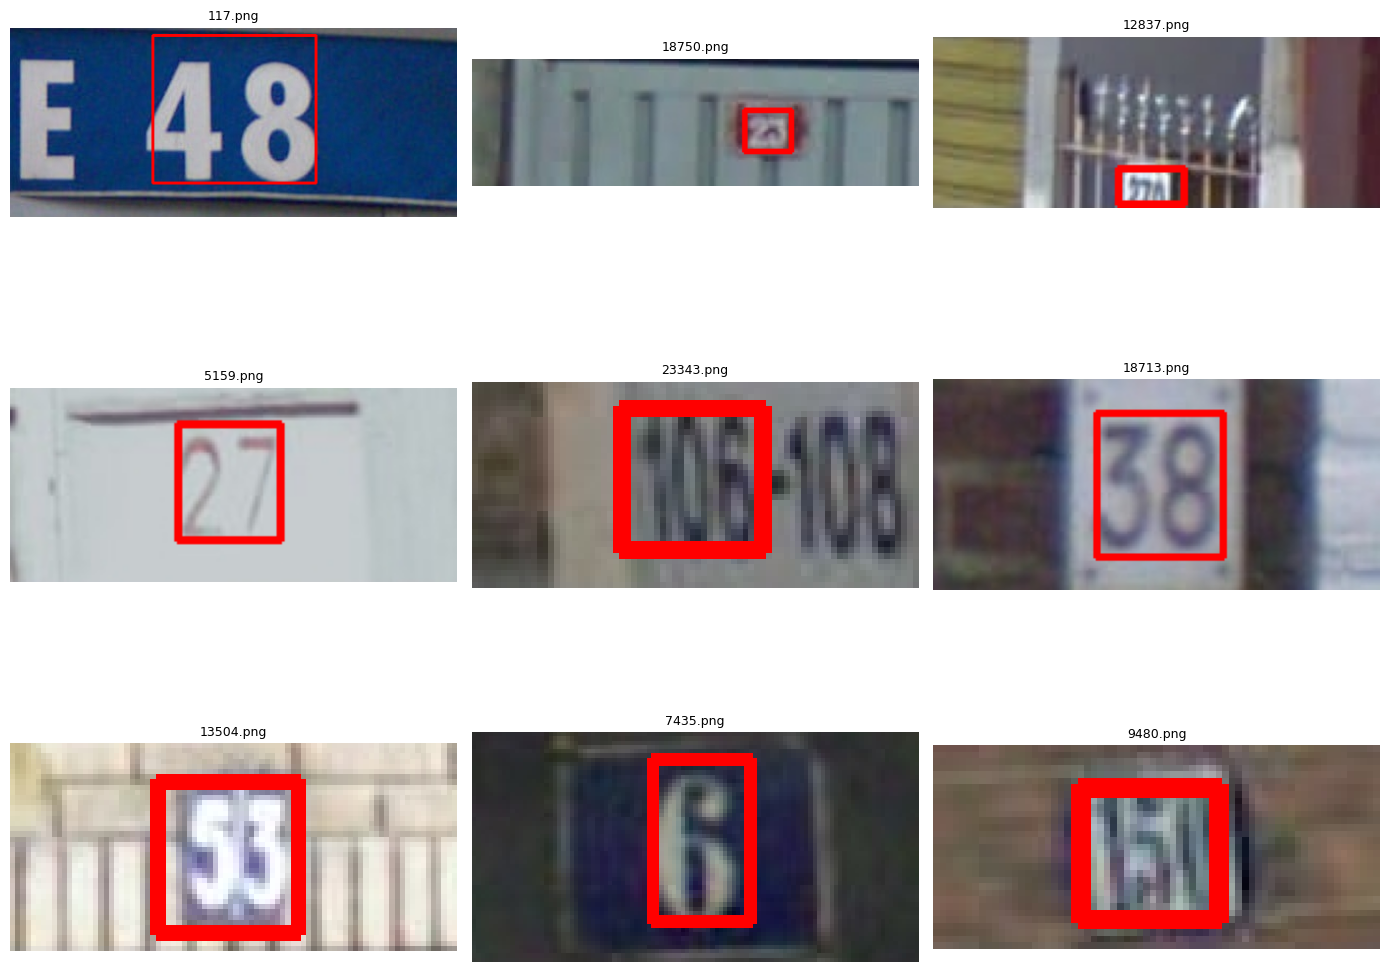

In [8]:
show_random_examples(
    svhn_root / 'images' / 'train',
    svhn_root / 'labels' / 'train',
    n=9,
    cols=3,
    figsize=(14, 12),
)

### Сводная статистика по bbox

Здесь рассчитываются простые характеристики разметки: размеры изображений, относительная площадь номера на кадре и соотношение сторон bounding box. Эти значения помогают понять, с какими по масштабу и форме объектами предстоит работать модели.

In [9]:
svhn_stats = summarize_labels(
    svhn_root / 'images' / 'train',
    svhn_root / 'labels' / 'train',
)
svhn_stats.head()

,image,width,height,bbox_area_ratio,aspect_ratio
0,1.png,741,350,0.148753,0.775784
1,10.png,74,37,0.243609,0.793104
2,100.png,67,27,0.305141,1.043478
3,1000.png,44,21,0.194805,0.555556
4,10000.png,137,62,0.161997,1.343752


### Распределение размеров объектов

На основе собранной статистики строится гистограмма относительной площади номера на изображении. По ней удобно оценить, преобладают ли в датасете крупные, средние или маленькие объекты, и нет ли сильного перекоса в масштабе.

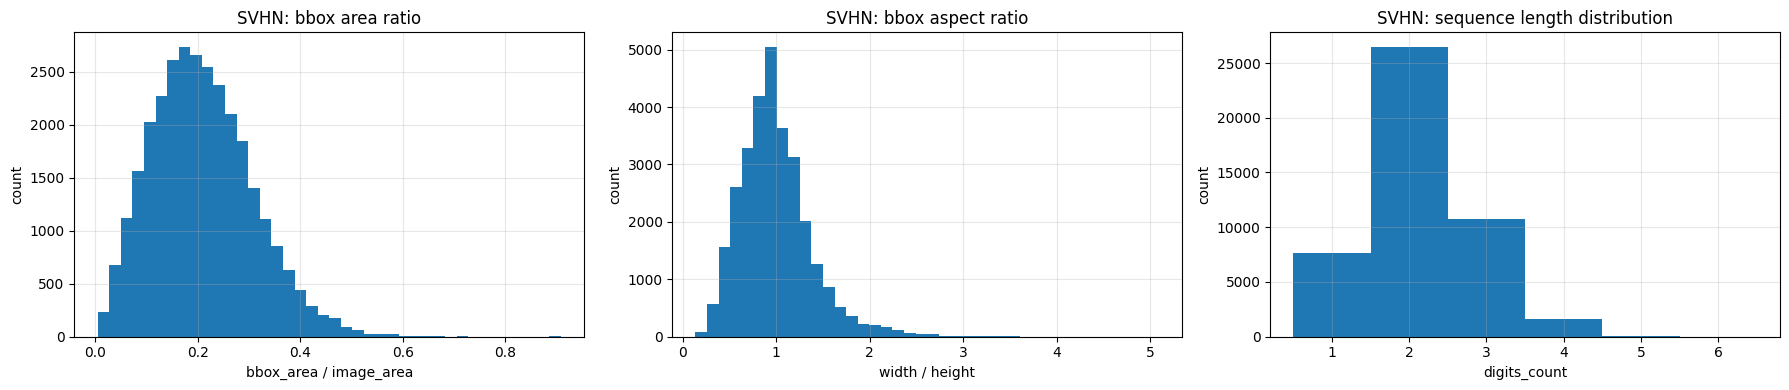

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(svhn_stats['bbox_area_ratio'], bins=40)
axes[0].set_title('SVHN: bbox area ratio')
axes[0].set_xlabel('bbox_area / image_area')
axes[0].set_ylabel('count')
axes[0].grid(True, alpha=0.3)

axes[1].hist(svhn_stats['aspect_ratio'], bins=40)
axes[1].set_title('SVHN: bbox aspect ratio')
axes[1].set_xlabel('width / height')
axes[1].set_ylabel('count')
axes[1].grid(True, alpha=0.3)

axes[2].hist(
    svhn_manifest['digits_count'],
    bins=np.arange(1, svhn_manifest['digits_count'].max() + 2) - 0.5
)
axes[2].set_title('SVHN: sequence length distribution')
axes[2].set_xlabel('digits_count')
axes[2].set_ylabel('count')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Загрузка дополнительного датасета

Эта ячейка пытается получить датасет `NumberDetection` из Roboflow. Он используется как дополнительный этап предобучения, чтобы сначала адаптировать модель к задаче детекции номеров, а затем уже дообучать её на целевом наборе SVHN.

In [11]:
def fetch_numberdetection_dataset(cfg: LabConfig) -> Path | None:
    if ROBOFLOW_DATA_YAML.exists():
        print(f'Local dataset already exists: {ROBOFLOW_DATA_YAML}')
        return ROBOFLOW_DATA_YAML
    try:
        rf = Roboflow(api_key=cfg.roboflow_api_key)
        project = rf.workspace(cfg.roboflow_workspace).project(cfg.roboflow_project)
        version = project.version(cfg.roboflow_version)
        dataset = version.download('yolov8', location=str(CFG.raw_root / 'numberdetection'))
        yaml_path = Path(dataset.location) / 'data.yaml'
        if yaml_path.exists():
            print(f'Roboflow dataset downloaded: {yaml_path}')
            return yaml_path
    except Exception as exc:
        print(f'Failed to download NumberDetection automatically: {exc}')
    return None

numberdetection_data = fetch_numberdetection_dataset(CFG)
print(numberdetection_data)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/itmo_cv_lab2/data/raw/numberdetection in yolov8:: 100%|██████████| 2374/2374 [00:00<00:00, 14051.71it/s]

Roboflow dataset downloaded: /content/itmo_cv_lab2/data/raw/numberdetection/data.yaml
/content/itmo_cv_lab2/data/raw/numberdetection/data.yaml


### Просмотр примеров NumberDetection

Если датасет `NumberDetection` доступен, здесь отображаются случайные примеры его изображений и разметки. Такой просмотр нужен для качественной проверки: мы видим, насколько этот набор действительно похож на реальную задачу детекции номерных областей и подходит ли он для первого этапа обучения.

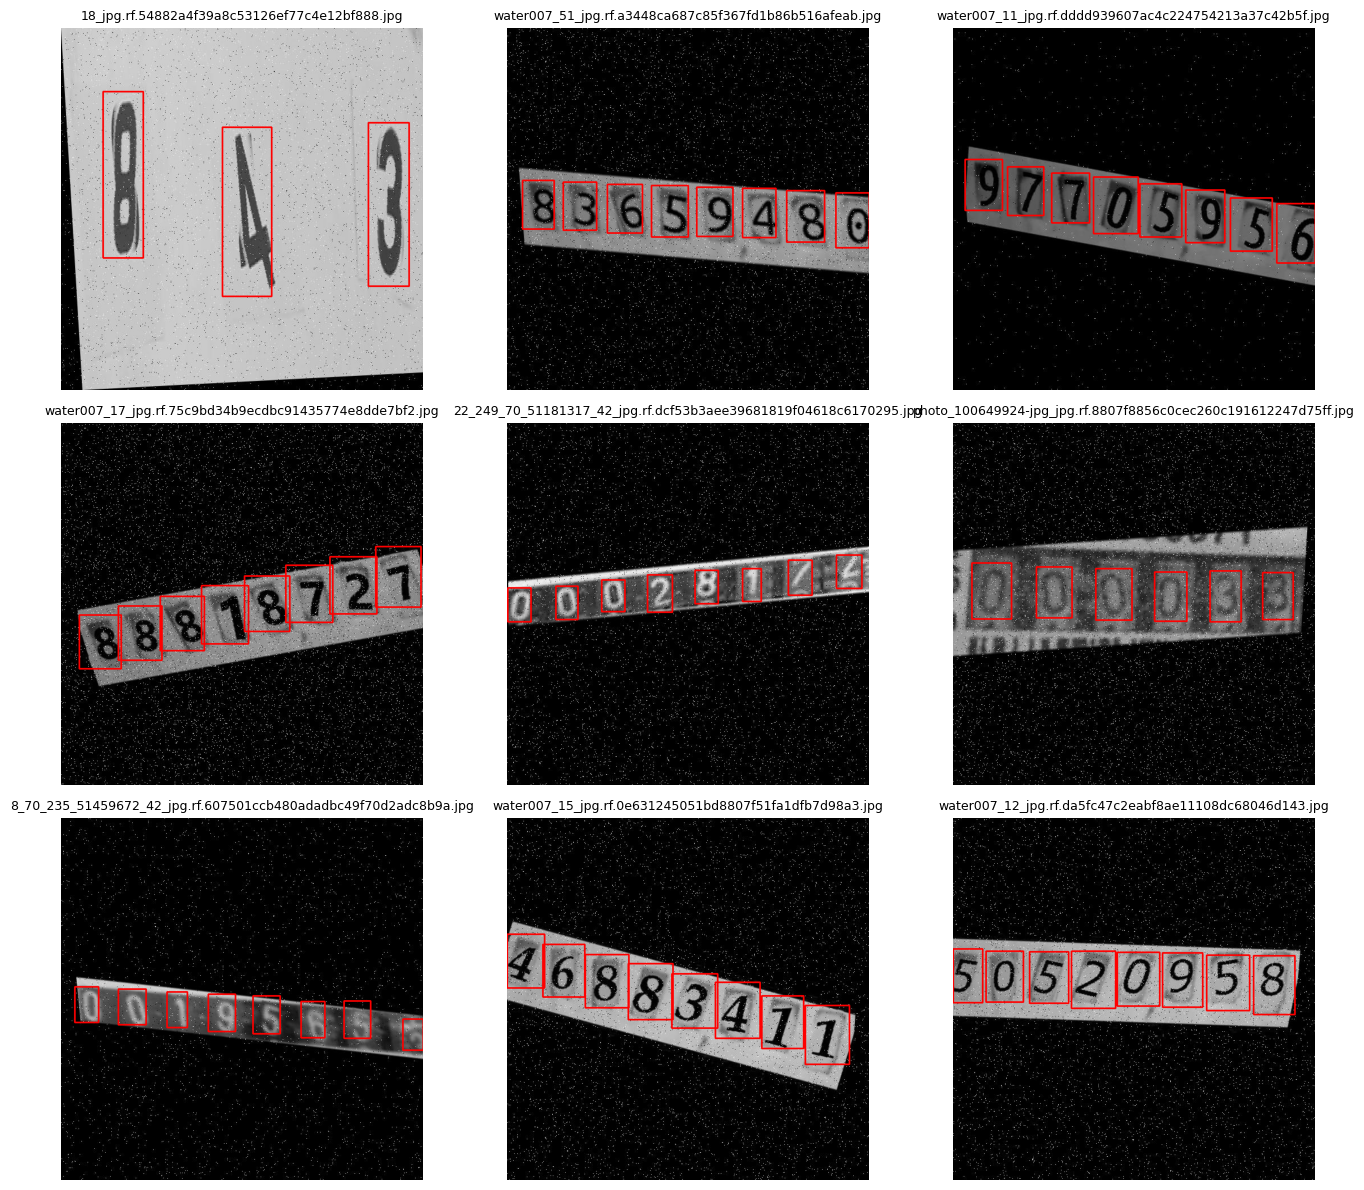

In [12]:
if numberdetection_data is not None:
    nd_root = Path(numberdetection_data).parent
    show_random_examples(
        nd_root / 'train' / 'images',
        nd_root / 'train' / 'labels',
        n=9,
        cols=3,
        figsize=(14, 12),
    )
else:
    print('Stage 1 will be skipped: NumberDetection dataset is unavailable.')

### Функция обучения модели

Ниже описывается универсальная функция запуска обучения YOLO. В ней централизованно задаются гиперпараметры, аугментации, способ сохранения результатов и экспорт лучших весов, чтобы оба этапа обучения выполнялись по одной схеме.

In [13]:
def train_detector_stage(
    initial_weights: str | Path,
    data_yaml: str | Path,
    run_name: str,
    epochs: int,
    cfg: LabConfig,
    extra_args: dict | None = None,
) -> Path:
    run_dir = cfg.runs_root / run_name
    best_weights = run_dir / 'weights' / 'best.pt'
    if cfg.reuse_existing_runs and best_weights.exists():
        print(f'Using existing run: {best_weights}')
        return best_weights

    train_args = dict(
      data=str(data_yaml),
      epochs=epochs,
      imgsz=cfg.img_size,
      batch=cfg.batch_size,
      workers=cfg.workers,
      device=cfg.device,
      project=str(cfg.runs_root),
      name=run_name,
      exist_ok=True,
      amp=False,
      cache=False,
      patience=cfg.patience,
      plots=True,
      save=True,
      cos_lr=True,
      close_mosaic=3,
      optimizer='auto',
      seed=cfg.seed,
      degrees=0.0,
      translate=0.05,
      scale=0.25,
      shear=0.0,
      perspective=0.0,
      fliplr=0.0,
      flipud=0.0,
      mosaic=0.5,
      mixup=0.0,
      hsv_h=0.015,
      hsv_s=0.4,
      hsv_v=0.2,
    )

    if extra_args:
        train_args.update(extra_args)

    model = YOLO(str(initial_weights))
    model.train(**train_args)

    best_weights = run_dir / 'weights' / 'best.pt'
    last_weights = run_dir / 'weights' / 'last.pt'
    if best_weights.exists():
        shutil.copy2(best_weights, cfg.model_root / f'{run_name}_best.pt')
    if last_weights.exists():
        shutil.copy2(last_weights, cfg.model_root / f'{run_name}_last.pt')
    gc.collect()
    return best_weights

### Этап 1: предварительное дообучение

На этом шаге модель при наличии `NumberDetection` сначала обучается на дополнительном датасете. Цель этапа состоит в том, чтобы дать сети более удачную стартовую точку перед основным обучением на SVHN; если датасет недоступен, этап корректно пропускается.

In [14]:
warmup_weights = CFG.model_name
if numberdetection_data is not None:
    warmup_weights = train_detector_stage(
        initial_weights=CFG.model_name,
        data_yaml=numberdetection_data,
        run_name='stage1_numberdetection',
        epochs=CFG.stage1_epochs,
        cfg=CFG,
    )
    print(f'Stage 1 best weights: {warmup_weights}')
else:
    print('Stage 1 skipped.')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/itmo_cv_lab2/data/raw/numberdetection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=6, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=stage1_numberdetection, nbs=64, nms=False, o

### Этап 2: основное обучение на SVHN

После возможного warm-up модель обучается на подготовленном датасете SVHN, где объектом считается весь номер целиком. Именно веса, полученные на этом этапе, затем используются для оценки качества и запуска инференса на собственных фотографиях.

In [15]:
detector_weights = train_detector_stage(
    initial_weights=warmup_weights,
    data_yaml=SVHN_DATA_YAML,
    run_name='stage2_svhn_full_number',
    epochs=CFG.stage2_epochs,
    cfg=CFG,
)
print(f'Stage 2 best weights: {detector_weights}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/itmo_cv_lab2/data/prepared/svhn_full_sequence.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=18, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/itmo_cv_lab2/runs/stage1_numberdetection/weights/best.pt, momentum=0.937, mosaic=0.5, multi_s

### Анализ кривых обучения

Здесь строятся графики `loss`, `precision`, `recall` и `mAP` по сохранённым логам обучения. По этим графикам можно оценить, как быстро обучается модель, есть ли переобучение и насколько полезным оказался предварительный этап на дополнительном датасете.

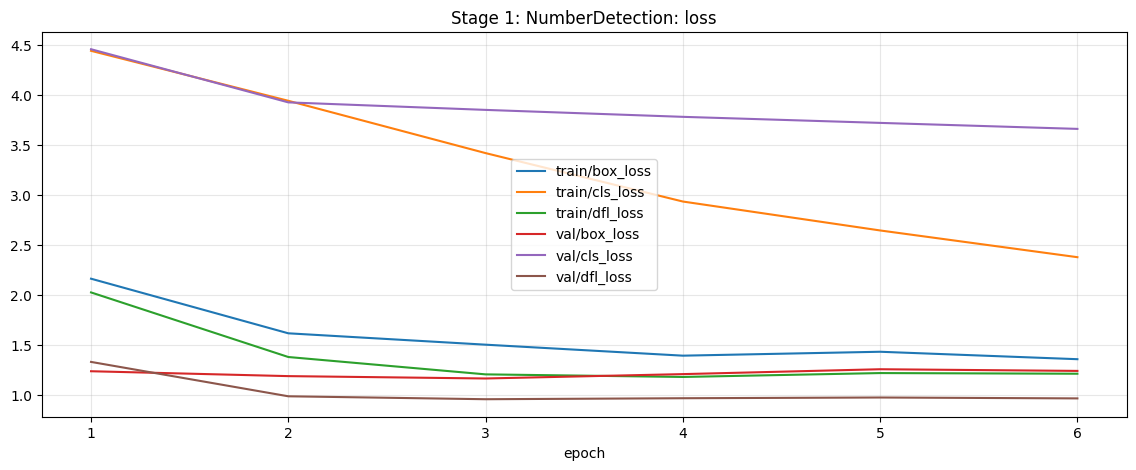

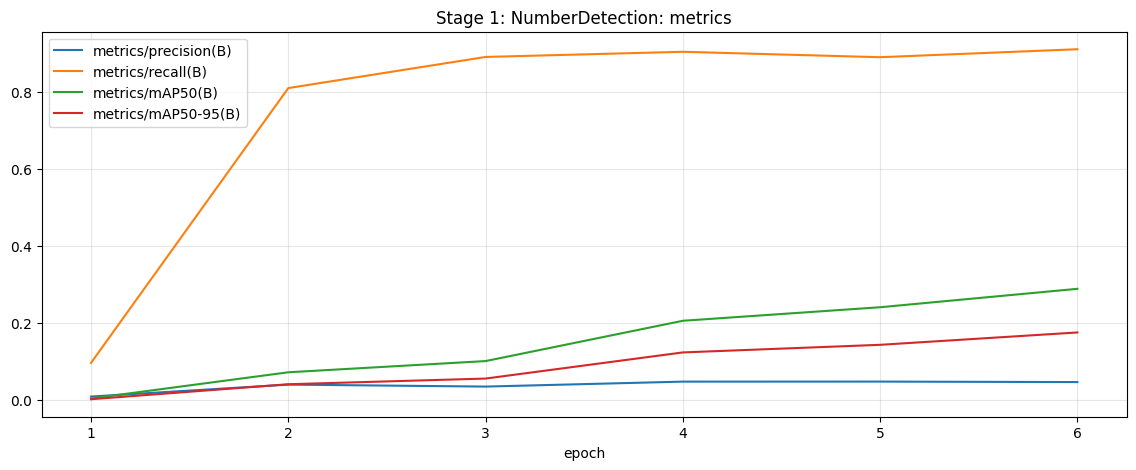

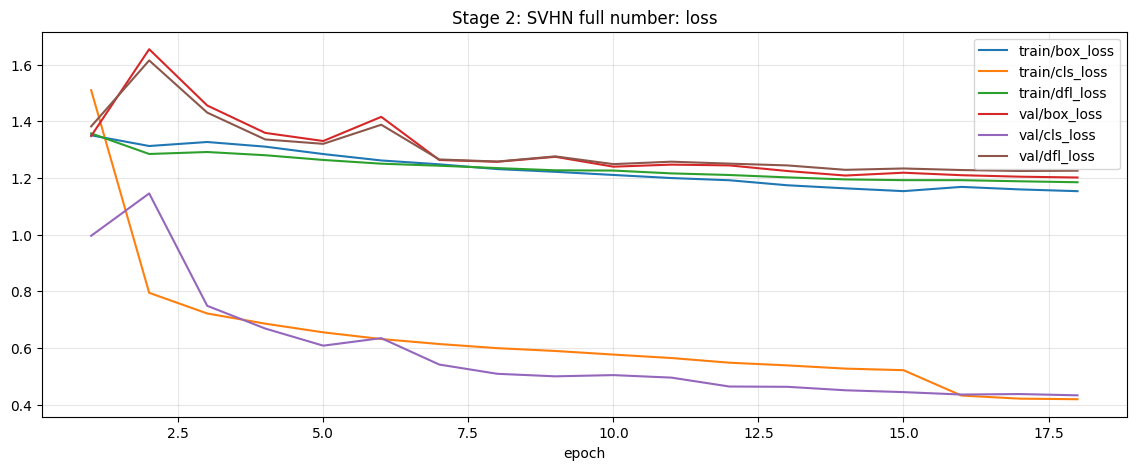

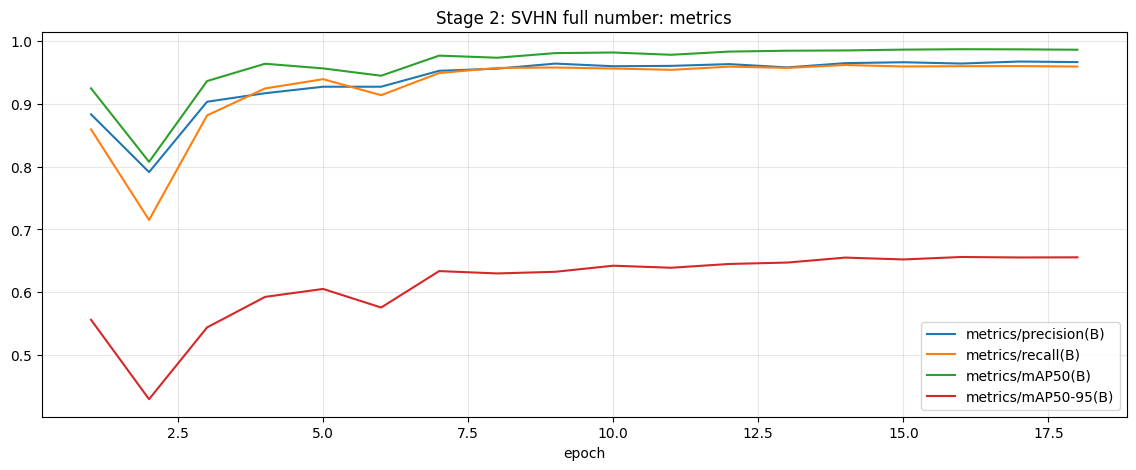

In [16]:
stage1_csv = CFG.runs_root / 'stage1_numberdetection' / 'results.csv'
stage2_csv = CFG.runs_root / 'stage2_svhn_full_number' / 'results.csv'

if numberdetection_data is not None:
    plot_training_curves(stage1_csv, 'Stage 1: NumberDetection')
plot_training_curves(stage2_csv, 'Stage 2: SVHN full number')

### Оценка на тестовой выборке

Эта ячейка запускает валидацию модели на тестовой части SVHN и собирает основные метрики качества: `Precision`, `Recall`, `mAP50`, `mAP50-95`. Дополнительно считается покадровая таблица с лучшим `IoU` и уверенностью предсказания, что позволяет затем провести более детальный анализ ошибок.

In [17]:
def benchmark_svhn_test_split(
    model_path: Path,
    cfg: LabConfig,
    batch_size: int | None = None,
    max_images: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    model = YOLO(str(model_path))
    batch_size = batch_size or cfg.batch_size
    val_metrics = model.val(
        data=str(SVHN_DATA_YAML),
        split='test',
        imgsz=cfg.img_size,
        batch=batch_size,
        device=cfg.device,
        conf=0.001,
        iou=0.6,
        plots=True,
        save_json=False,
        project=str(cfg.runs_root),
        name='svhn_test_eval',
        exist_ok=True,
        verbose=False,
    )

    test_images_dir = cfg.prepared_root / 'svhn_full_sequence' / 'images' / 'test'
    test_labels_dir = cfg.prepared_root / 'svhn_full_sequence' / 'labels' / 'test'
    image_paths = sorted([p for p in test_images_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])
    if max_images is not None:
        image_paths = image_paths[:max_images]

    rows = []
    tp = fp = fn = 0
    matched_ious = []

    for start in tqdm(range(0, len(image_paths), batch_size), desc='Custom test evaluation'):
        batch_paths = image_paths[start:start + batch_size]
        predictions = model.predict(
            source=[str(p) for p in batch_paths],
            imgsz=cfg.img_size,
            conf=cfg.conf_threshold,
            iou=0.6,
            device=cfg.device,
            verbose=False,
        )
        for src_path, prediction in zip(batch_paths, predictions):
            orig_h, orig_w = prediction.orig_shape
            gt_label_path = test_labels_dir / f'{Path(src_path).stem}.txt'
            gt_rows = load_yolo_boxes(gt_label_path, orig_w, orig_h)
            gt_box = gt_rows[0][1:] if gt_rows else None

            pred_boxes = prediction.boxes.xyxy.cpu().numpy().tolist() if prediction.boxes is not None and len(prediction.boxes) else []
            pred_scores = prediction.boxes.conf.cpu().numpy().tolist() if prediction.boxes is not None and len(prediction.boxes) else []

            best_box = None
            best_conf = None
            best_iou = 0.0
            if gt_box is not None and pred_boxes:
                ious = [iou_xyxy(gt_box, box) for box in pred_boxes]
                best_idx = int(np.argmax(ious))
                best_box = pred_boxes[best_idx]
                best_conf = pred_scores[best_idx]
                best_iou = float(ious[best_idx])
            elif pred_boxes:
                best_box = pred_boxes[0]
                best_conf = pred_scores[0]

            has_gt = gt_box is not None
            has_pred = best_box is not None
            matched = has_gt and has_pred and best_iou >= cfg.iou_threshold

            if matched:
                tp += 1
                matched_ious.append(best_iou)
            elif has_gt and has_pred:
                fp += 1
                fn += 1
            elif has_gt and not has_pred:
                fn += 1
            elif (not has_gt) and has_pred:
                fp += 1

            rows.append({
                'image': Path(src_path).name,
                'has_gt': has_gt,
                'has_pred': has_pred,
                'best_conf': float(best_conf) if best_conf is not None else 0.0,
                'best_iou': best_iou,
                'matched': matched,
            })

    precision_custom = tp / max(1, tp + fp)
    recall_custom = tp / max(1, tp + fn)
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    summary = pd.DataFrame([{
        'images_evaluated': len(image_paths),
        'precision_val_api': float(val_metrics.box.mp),
        'recall_val_api': float(val_metrics.box.mr),
        'mAP50': float(val_metrics.box.map50),
        'mAP50-95': float(val_metrics.box.map),
        'precision_custom@0.5IoU': precision_custom,
        'recall_custom@0.5IoU': recall_custom,
        'mean_iou_matched': mean_iou,
        'matched_samples': len(matched_ious),
    }])

    eval_dir = cfg.runs_root / 'svhn_test_eval'
    eval_dir.mkdir(parents=True, exist_ok=True)
    per_image = pd.DataFrame(rows).sort_values(['matched', 'best_iou'], ascending=[True, True]).reset_index(drop=True)
    summary.to_csv(eval_dir / 'test_summary.csv', index=False)
    per_image.to_csv(eval_dir / 'test_per_image.csv', index=False)
    return summary, per_image

test_summary, test_per_image = benchmark_svhn_test_split(detector_weights, CFG)
display(test_summary)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1856.4±3034.6 MB/s, size: 35.4 KB)
val: Scanning /content/itmo_cv_lab2/data/prepared/svhn_full_sequence/labels/test... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 7.6Kit/s 1.7s
val: New cache created: /content/itmo_cv_lab2/data/prepared/svhn_full_sequence/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 6.8it/s 15.2s
                   all      13068      13068      0.896      0.888      0.929      0.531
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/itmo_cv_lab2/runs/svhn_test_eval


Custom test evaluation:   0%|          | 0/103 [00:00<?, ?it/s]

,images_evaluated,precision_val_api,recall_val_api,mAP50,mAP50-95,precision_custom@0.5IoU,recall_custom@0.5IoU,mean_iou_matched,matched_samples
0,13068,0.895728,0.888083,0.928679,0.531061,0.918839,0.898378,0.792636,11740


### Анализ распределения IoU и confidence

После расчёта метрик полезно посмотреть не только средние значения, но и распределения по отдельным изображениям. Эти гистограммы показывают, насколько стабильно модель попадает в объект и как уверенно она делает предсказания на тестовой выборке.

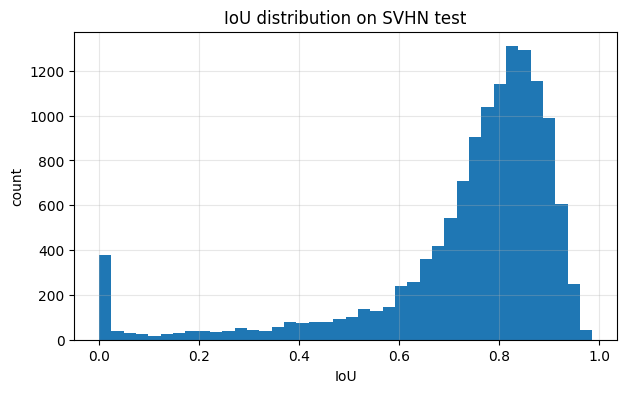

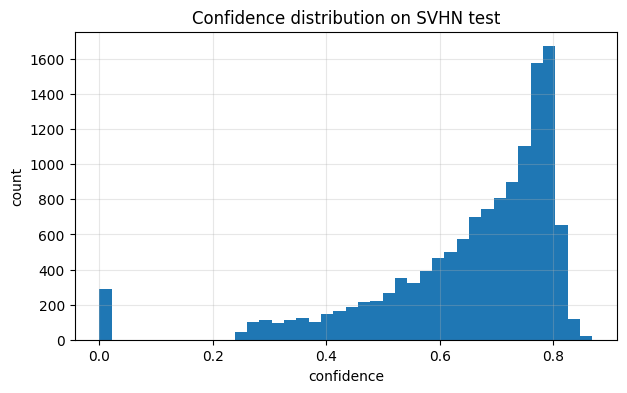

In [18]:
plt.figure(figsize=(7, 4))
plt.hist(test_per_image['best_iou'], bins=40)
plt.title('IoU distribution on SVHN test')
plt.xlabel('IoU')
plt.ylabel('count')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(test_per_image['best_conf'], bins=40)
plt.title('Confidence distribution on SVHN test')
plt.xlabel('confidence')
plt.ylabel('count')
plt.grid(True, alpha=0.3)
plt.show()

### Функция визуализации предсказаний

Ниже определяется функция, которая рисует на изображениях предсказанные моделью bounding boxes и, при наличии, эталонную разметку. Такой инструмент нужен для качественного анализа поведения модели, когда одних численных метрик недостаточно.

In [19]:
def preview_detections(model_path: Path, image_paths: list[Path], labels_dir: Path | None = None, ncols: int = 3, figsize=(15, 10)) -> None:
    if not image_paths:
        print('No images to display.')
        return
    model = YOLO(str(model_path))
    predictions = list(model.predict(source=[str(p) for p in image_paths], imgsz=CFG.img_size, conf=CFG.conf_threshold, verbose=False))
    nrows = math.ceil(len(predictions) / ncols)
    plt.figure(figsize=figsize)
    for i, (src_path, prediction) in enumerate(zip(image_paths, predictions), start=1):
        image = read_rgb_image(src_path)
        vis = image.copy()
        if labels_dir is not None:
            h, w = image.shape[:2]
            gt = load_yolo_boxes(labels_dir / f'{Path(src_path).stem}.txt', w, h)
            vis = draw_xyxy_boxes(vis, gt, color=(0, 255, 0), width=2)
        if prediction.boxes is not None and len(prediction.boxes) > 0:
            pred_boxes = prediction.boxes.xyxy.cpu().numpy().tolist()
            pred_scores = prediction.boxes.conf.cpu().numpy().tolist()
            for box, score in zip(pred_boxes, pred_scores):
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(vis, f'{score:.2f}', (x1, max(12, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
        plt.subplot(nrows, ncols, i)
        plt.imshow(vis)
        plt.title(Path(src_path).name, fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Лучшие и сложные примеры

В этой ячейке выбираются несколько самых удачных и самых сложных изображений из тестовой части по значению `IoU`. Это позволяет увидеть, в каких условиях модель работает хорошо, а где чаще ошибается: на мелких объектах, сложном фоне, смещении или плохом кадрировании.

Best examples


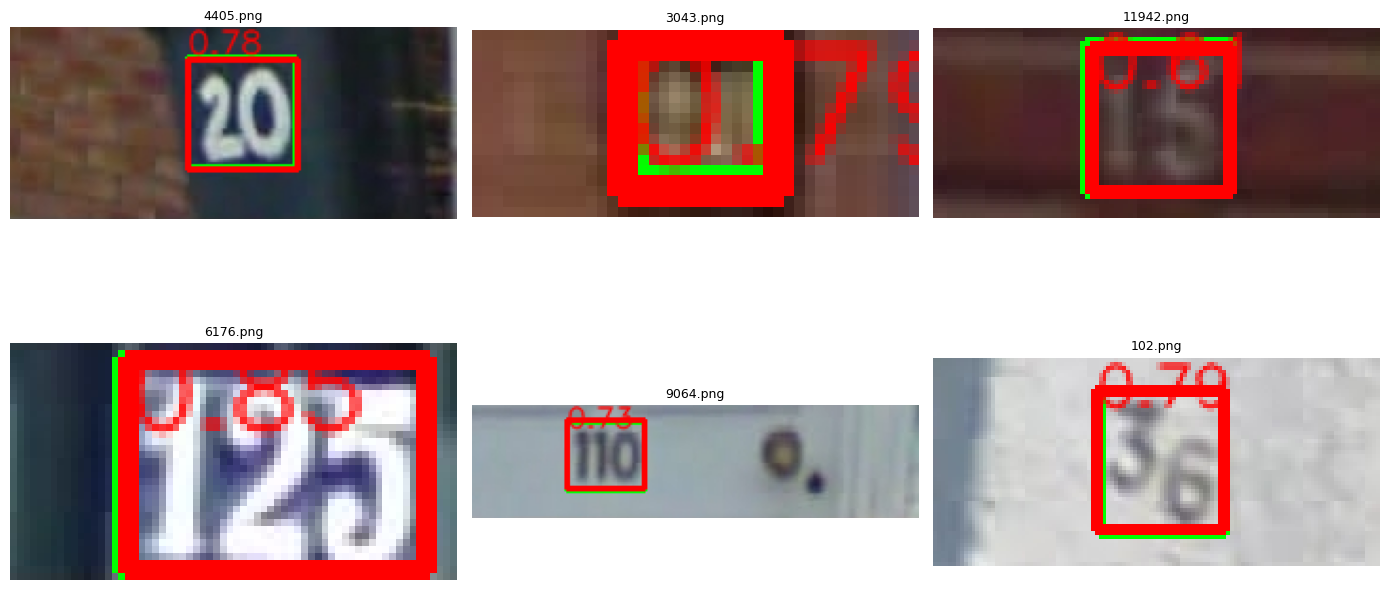

Hard examples


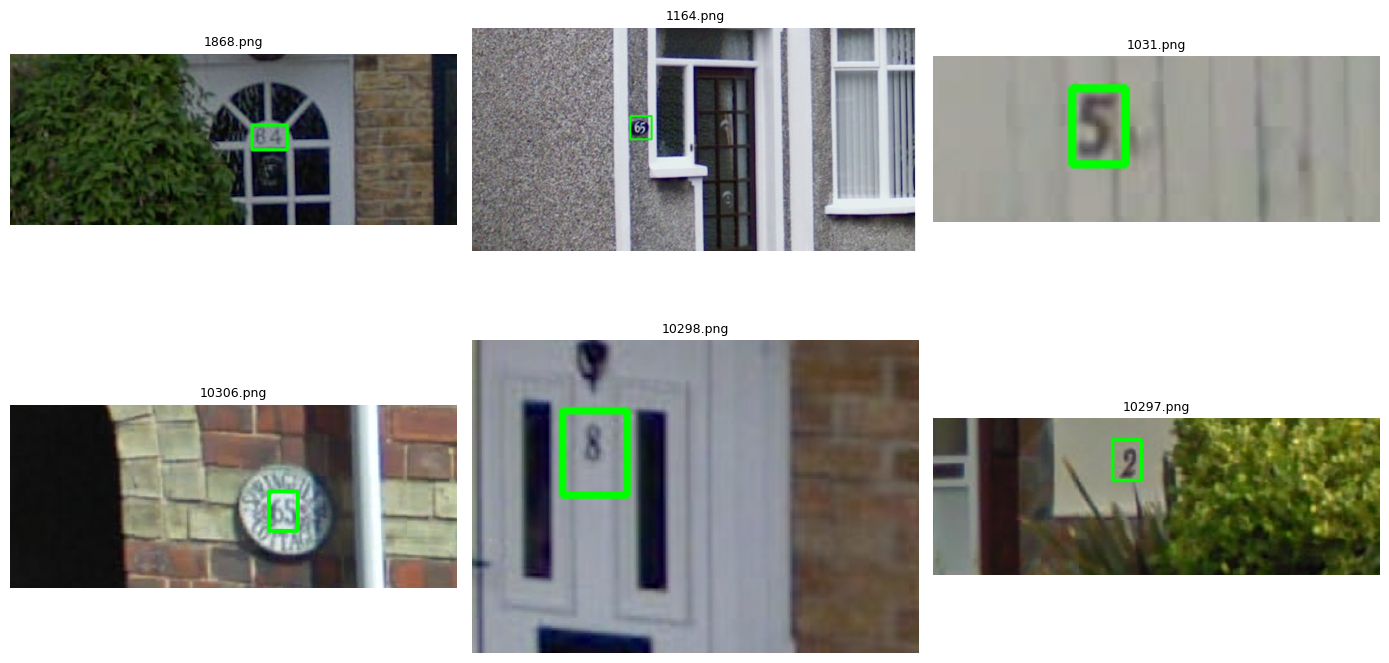

In [20]:
test_images_dir = CFG.prepared_root / 'svhn_full_sequence' / 'images' / 'test'
test_labels_dir = CFG.prepared_root / 'svhn_full_sequence' / 'labels' / 'test'

best_examples = test_per_image.sort_values('best_iou', ascending=False).head(6)['image'].tolist()
worst_examples = test_per_image.sort_values('best_iou', ascending=True).head(6)['image'].tolist()

print('Best examples')
preview_detections(
    detector_weights,
    [test_images_dir / name for name in best_examples],
    labels_dir=test_labels_dir,
    ncols=3,
    figsize=(14, 8),
)

print('Hard examples')
preview_detections(
    detector_weights,
    [test_images_dir / name for name in worst_examples],
    labels_dir=test_labels_dir,
    ncols=3,
    figsize=(14, 8),
)

### Сохранённые веса модели

Ниже начинается небольшой служебный раздел, посвящённый экспортированным чекпоинтам. Он нужен для того, чтобы явно показать, какие файлы весов были получены после этапов обучения и какие из них используются дальше в работе.

## Exported Checkpoints

В этом разделе перечисляются сохранённые контрольные точки модели. Обычно здесь находятся лучшие и последние веса после каждого этапа обучения, что удобно для последующих экспериментов, переоценки модели и инференса.

### Список доступных checkpoint-файлов

Эта ячейка выводит таблицу с путями ко всем `.pt`-файлам, которые были сохранены в ходе обучения. По ней можно быстро понять, какие версии модели доступны и какие веса стоит использовать в дальнейших шагах.

In [21]:
pd.DataFrame({'model_path': [str(path) for path in sorted(CFG.model_root.glob('*.pt'))]})

,model_path
0,/content/itmo_cv_lab2/models/stage1_numberdete...
1,/content/itmo_cv_lab2/models/stage1_numberdete...
2,/content/itmo_cv_lab2/models/stage2_svhn_full_...
3,/content/itmo_cv_lab2/models/stage2_svhn_full_...


### Функция пакетного инференса

Ниже описана функция, которая запускает модель на всей папке изображений, сохраняет результаты детекции и формирует итоговую таблицу с координатами и уверенностью найденных объектов. Этот блок нужен для массовой обработки собственных фотографий без ручного запуска по одному файлу.

In [22]:
def run_folder_inference(model_path: Path, source_dir: Path, out_dir: Path, imgsz: int = 640, conf: float = 0.25, device: int | str = 'cpu') -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)
    device = pick_runtime_device(device)
    model = YOLO(str(model_path))
    predictions = list(model.predict(
        source=str(source_dir),
        imgsz=imgsz,
        conf=conf,
        device=device,
        save=True,
        project=str(out_dir.parent),
        name=out_dir.name,
        exist_ok=True,
        verbose=False,
    ))
    rows = []
    for prediction in predictions:
        image_path = Path(prediction.path)
        if prediction.boxes is None or len(prediction.boxes) == 0:
            rows.append({'image': image_path.name, 'detections': 0, 'top_conf': 0.0, 'x1': None, 'y1': None, 'x2': None, 'y2': None})
            continue
        boxes = prediction.boxes.xyxy.cpu().numpy()
        confs = prediction.boxes.conf.cpu().numpy()
        best_idx = int(np.argmax(confs))
        x1, y1, x2, y2 = boxes[best_idx].tolist()
        rows.append({
            'image': image_path.name,
            'detections': int(len(boxes)),
            'top_conf': float(confs[best_idx]),
            'x1': float(x1),
            'y1': float(y1),
            'x2': float(x2),
            'y2': float(y2),
        })
    result_df = pd.DataFrame(rows).sort_values('image').reset_index(drop=True)
    result_df.to_csv(out_dir / 'inference_summary.csv', index=False)
    return result_df

### Инференс на собственных фотографиях

На этом этапе модель применяется к фотографиям, сделанным самостоятельно и сохранённым в папке `my_photos`. Для удобства запуска в Google Colab, если папка пуста, ноутбук автоматически предложит загрузить изображения через диалог `Upload`, после чего выполнит инференс и покажет сводную таблицу по результатам.


In [23]:
street_photo_paths = ensure_personal_photos(CFG)
print(f'Using photos from: {CFG.personal_photos_root}')

if not street_photo_paths:
    print('The photo folder is empty. Add images to the my_photos folder or upload them through the Colab dialog.')
else:
    street_results = run_folder_inference(
        model_path=detector_weights,
        source_dir=CFG.personal_photos_root,
        out_dir=CFG.inference_root / 'street_photos_pred',
        imgsz=CFG.img_size,
        conf=CFG.conf_threshold,
        device=CFG.device,
    )
    display(street_results)


Using photos from: /content/itmo_cv_lab2/my_photos
Results saved to /content/itmo_cv_lab2/inference/street_photos_pred


,image,detections,top_conf,x1,y1,x2,y2
0,IMG_9844.png,0,0.000000,NaN,NaN,NaN,NaN
1,IMG_9845.png,1,0.255344,1279.421509,1927.353027,1689.039917,2258.248047
2,IMG_9847.png,2,0.389327,1211.154663,1967.763428,1689.318237,2370.274414
3,IMG_9848.png,1,0.522283,1299.771362,669.941711,1947.110352,3127.229492
4,IMG_9849.png,2,0.465401,1548.342041,2865.283936,1919.696289,3253.486572
5,IMG_9850.png,1,0.505993,1749.915405,2215.405029,1991.987061,2536.149414


### Детальная визуализация результатов

Финальная ячейка подробно показывает детекции на собственных фотографиях, сохраняет аннотированные изображения и формирует таблицу по каждому найденному bounding box. После адаптации под Colab этот шаг использует те же загруженные через браузер изображения, поэтому блок можно запускать сразу после предыдущей ячейки без дополнительной ручной подготовки файлов.


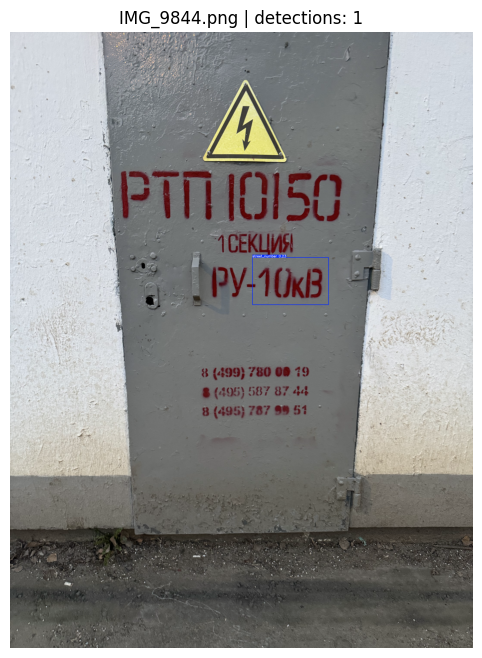

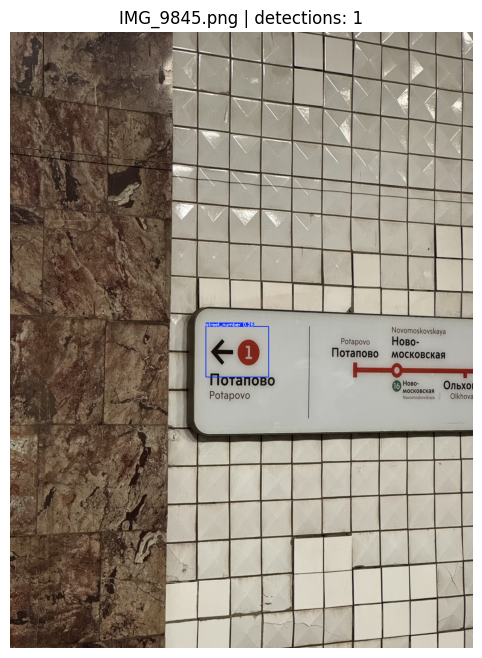

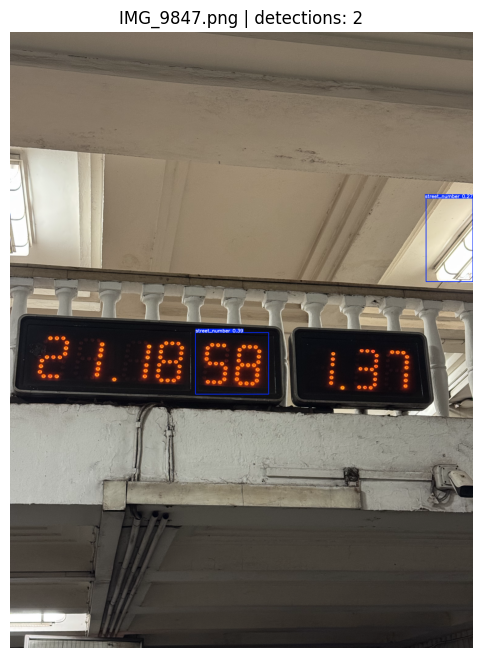

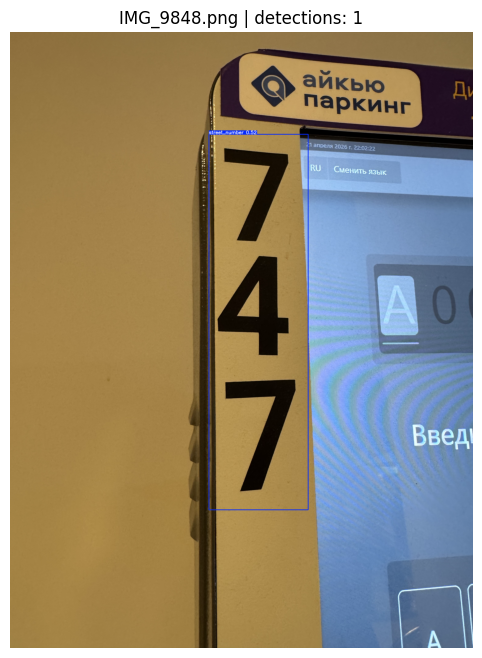

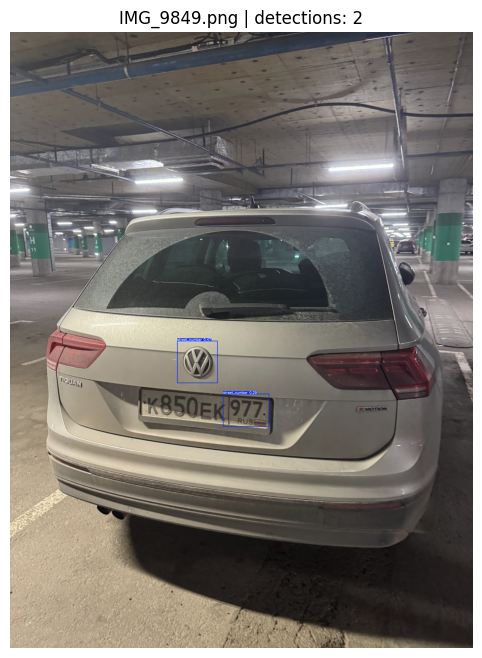

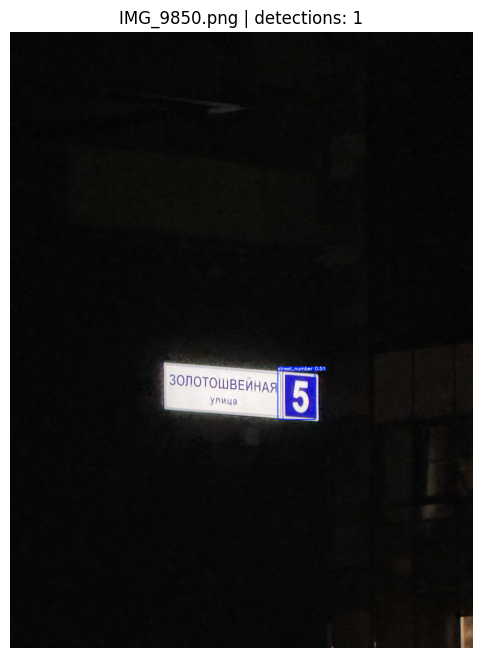

,image,det_id,conf,x1,y1,x2,y2,width,height
0,IMG_9844.png,1,0.228998,2243,2090,2947,2528,704,438
1,IMG_9845.png,1,0.255344,1279,1927,1689,2258,410,331
2,IMG_9847.png,1,0.389327,1211,1967,1689,2370,478,403
3,IMG_9847.png,2,0.273264,2717,1087,3023,1633,306,546
4,IMG_9848.png,1,0.522283,1299,669,1947,3127,648,2458
5,IMG_9849.png,1,0.465401,1548,2865,1919,3253,371,388
6,IMG_9849.png,2,0.287556,1972,3356,2396,3657,424,301
7,IMG_9850.png,1,0.505993,1749,2215,1991,2536,242,321


Annotated images were saved to: /content/itmo_cv_lab2/inference/street_photos_boxes


In [24]:
source_dir = CFG.personal_photos_root
save_dir = CFG.inference_root / 'street_photos_boxes'
save_dir.mkdir(parents=True, exist_ok=True)

image_paths = ensure_personal_photos(CFG)
model = YOLO(str(detector_weights))
rows = []

for image_path in image_paths:
    prediction = model.predict(
        source=str(image_path),
        imgsz=CFG.img_size,
        conf=0.20,
        iou=0.50,
        device=CFG.device,
        verbose=False,
    )[0]

    annotated_bgr = prediction.plot(line_width=3, font_size=18)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    cv2.imwrite(str(save_dir / image_path.name), annotated_bgr)

    detections_count = 0 if prediction.boxes is None else len(prediction.boxes)
    if prediction.boxes is not None and len(prediction.boxes) > 0:
        boxes_xyxy = prediction.boxes.xyxy.cpu().numpy()
        confs = prediction.boxes.conf.cpu().numpy()
        for idx, (box, conf) in enumerate(zip(boxes_xyxy, confs), start=1):
            x1, y1, x2, y2 = box.astype(int)
            rows.append({
                'image': image_path.name,
                'det_id': idx,
                'conf': float(conf),
                'x1': int(x1),
                'y1': int(y1),
                'x2': int(x2),
                'y2': int(y2),
                'width': int(x2 - x1),
                'height': int(y2 - y1),
            })
    else:
        rows.append({
            'image': image_path.name,
            'det_id': 0,
            'conf': None,
            'x1': None,
            'y1': None,
            'x2': None,
            'y2': None,
            'width': None,
            'height': None,
        })

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_rgb)
    plt.title(f'{image_path.name} | detections: {detections_count}')
    plt.axis('off')
    plt.show()

personal_det_table = pd.DataFrame(rows)
display(personal_det_table)
print(f'Annotated images were saved to: {save_dir}')
